In [1]:
from astropy.io import ascii
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import galstreams


In [2]:
tbl_data = ascii.read(
    "../data/apjad382dt1_mrt.txt",
    format="cds"   
)

tbl_ids = pd.read_csv("../data/gaia_stream_id.csv", 
                      sep='\t')

print(tbl_data.colnames)
print(tbl_ids.columns)

tbl_ids[(tbl_ids['Name'] == 'Fjorm') | (tbl_ids['Name'] == 'Gjoll') | (tbl_ids['Name'] == 'Pal-5')]

['Gaia', 'RAdeg', 'DEdeg', 'plx', 'pmRA', 'pmDE', 'Gmag', '(B-R)', 'VHel', 'e_VHel', 'r_VHel', 'Stream']
Index(['s_ID', 'Name', 'Sample', 'alpha_0', 'alpha_pole', 'delta_pole', 'n',
       'n _v', 'M_sstarf', 'angl0[Fe/H]angr0', 'References', 'Remarks',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23'],
      dtype='object')


,s_ID,Name,Sample,alpha_0,alpha_pole,delta_pole,n,n _v,M_sstarf,angl0[Fe/H]angr0,...,Unnamed: 14,Unnamed: 15,Unnamed: 16,Unnamed: 17,Unnamed: 18,Unnamed: 19,Unnamed: 20,Unnamed: 21,Unnamed: 22,Unnamed: 23
33,34,Gjoll,1,154.403,158.539,43.545,607,40,2100,-1.63,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,47,Fjorm,1,189.867,103.086,19.455,297,29,1700,-2.23,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
60,61,Pal-5,1,229.022,320.298,-54.042,129,69,"17,000",-1.41,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Pal5: 129 stars
NGC3201: 607 stars
M68: 297 stars


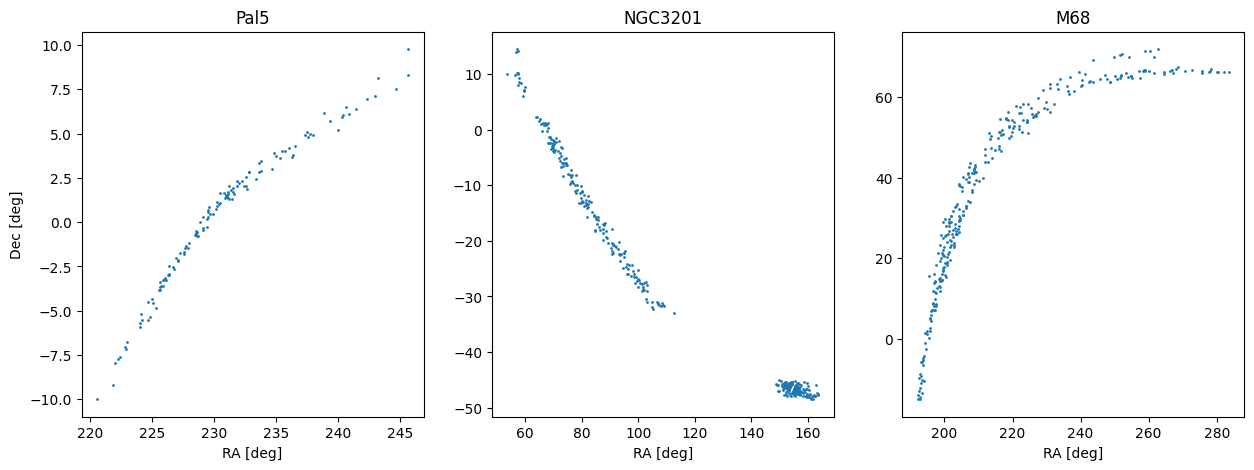

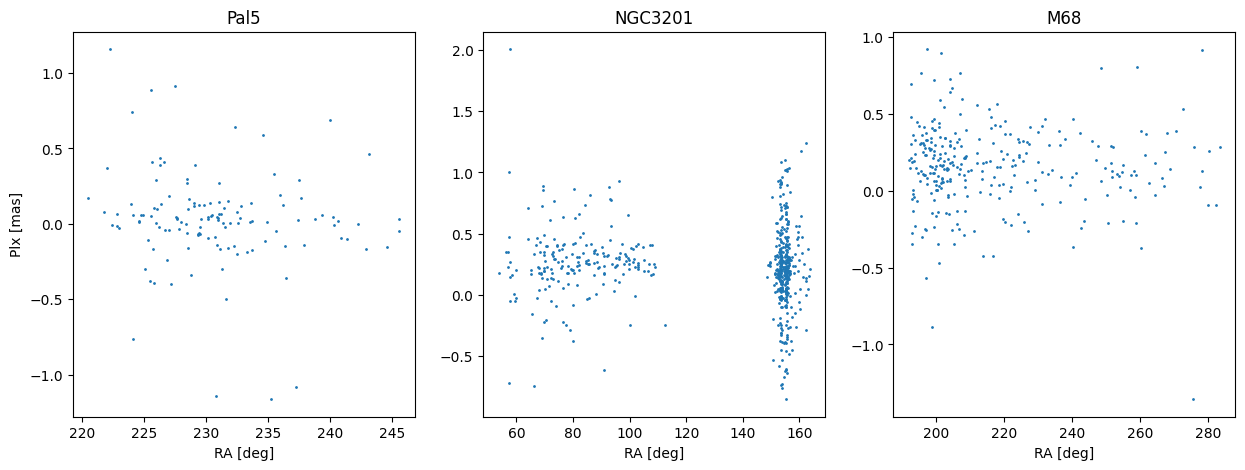

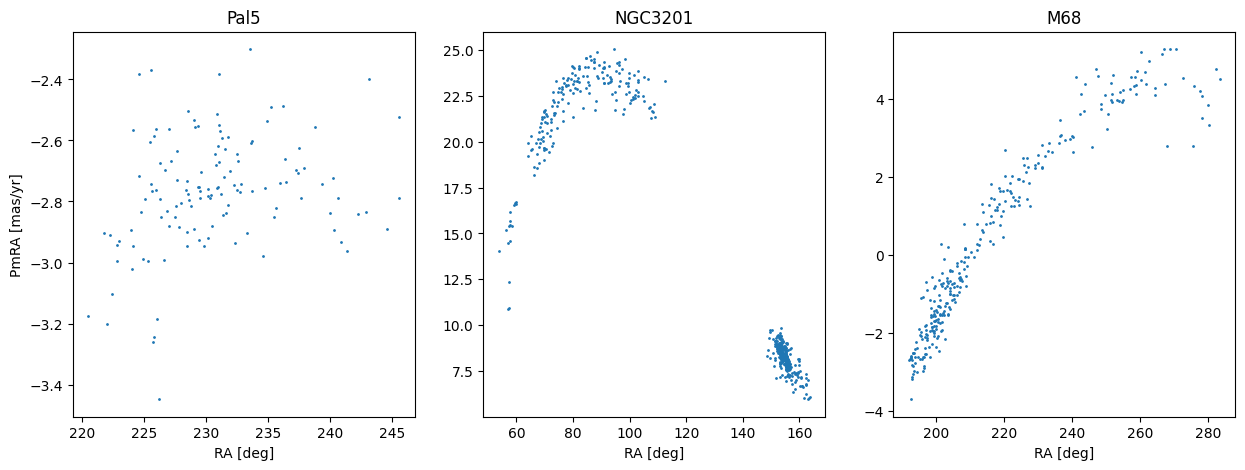

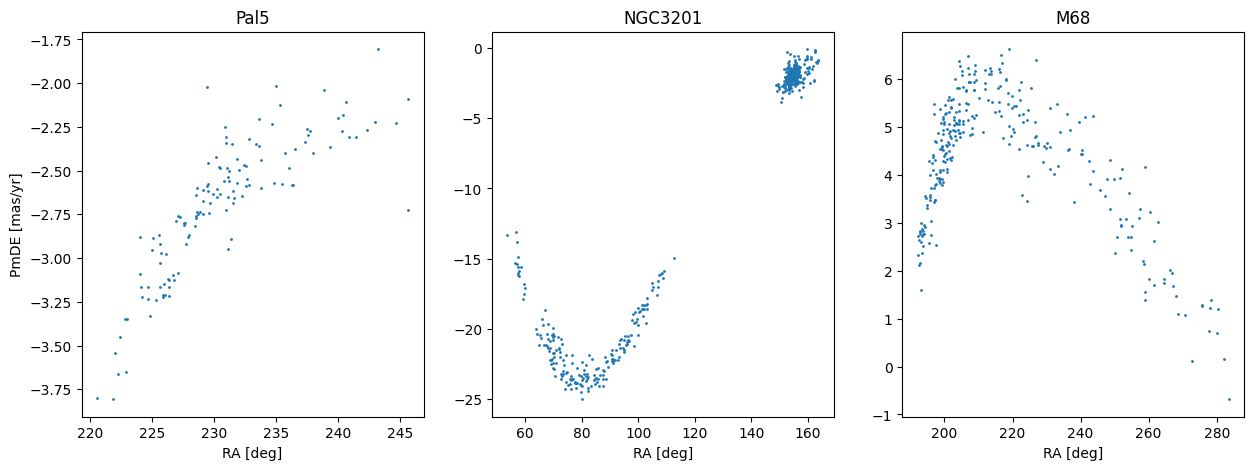

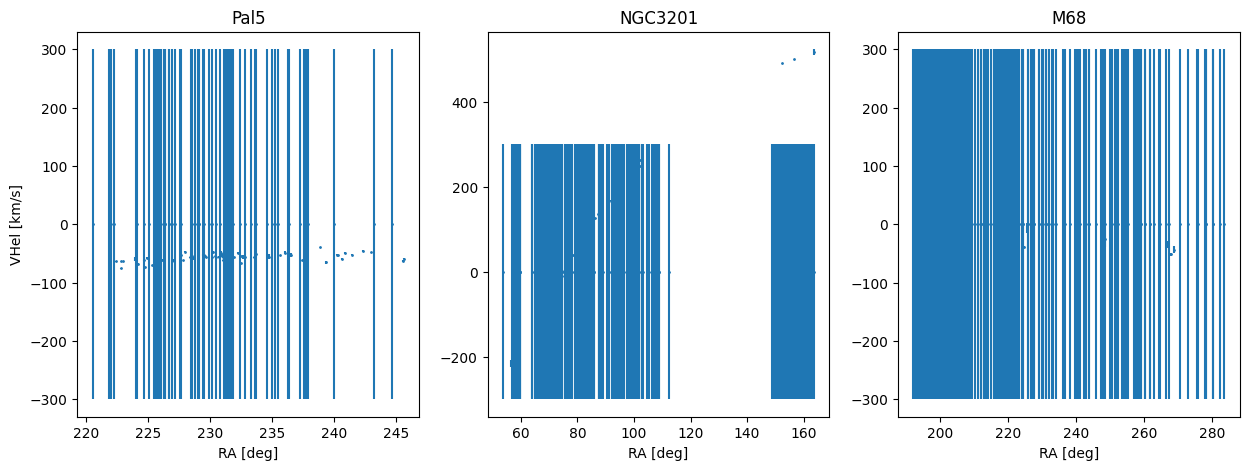

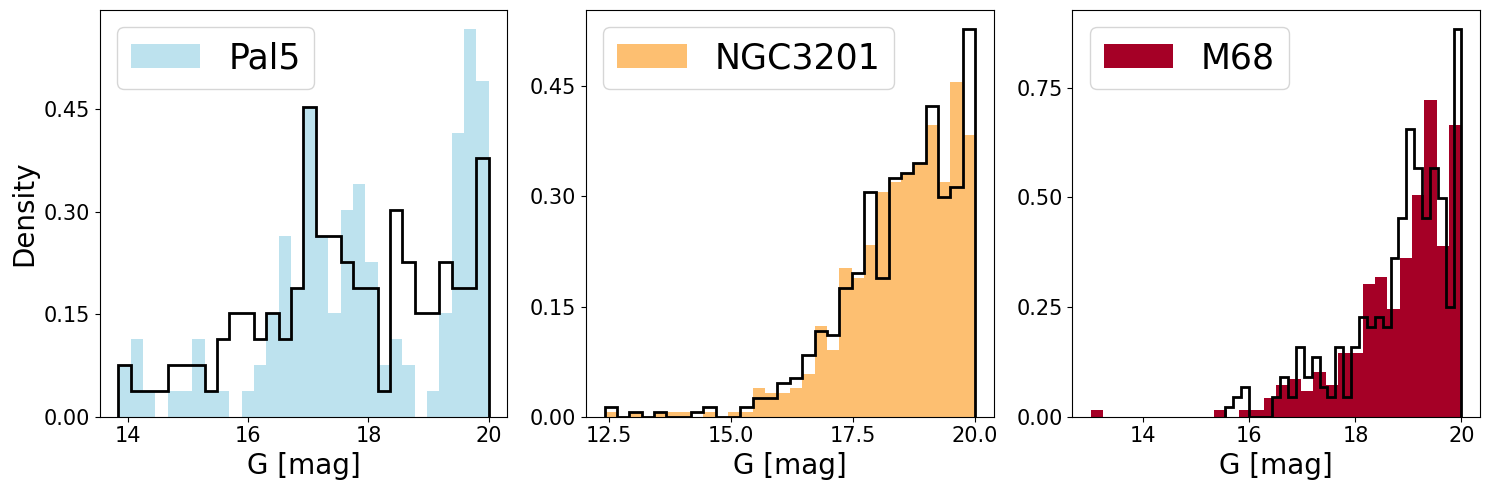

In [3]:
name_to_plot = ['Pal5', 'NGC3201', 'M68']
name_for_id = ['Pal-5', 'Gjoll', 'Fjorm']
particles = {}


for name_id, name_plot in zip(name_for_id, name_to_plot):
    source_id = tbl_ids.loc[tbl_ids['Name'] == name_id, 's_ID'].values[0]
    tbl_subset = tbl_data[tbl_data['Stream'] == source_id]
    print(f"{name_plot}: {len(tbl_subset)} stars")
    particles[name_plot] = {'Ra': np.array([a for a in tbl_subset['RAdeg']]),\
                            'Dec': np.array([a for a in tbl_subset['DEdeg']]),\
                            'Plx': np.array([a for a in tbl_subset['plx']]),\
                            'PmRA': np.array([a for a in tbl_subset['pmRA']]),\
                            'PmDE': np.array([a for a in tbl_subset['pmDE']]),\
                            'VHel': np.array([a for a in tbl_subset['VHel']]),\
                            'e_VHel': np.array([a for a in tbl_subset['e_VHel']]),\
                            'Gmag': np.array([a for a in tbl_subset['Gmag']]),\
                            'r_VHel': np.array([a for a in tbl_subset['r_VHel']])
                            }

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(particles[name]['Ra'], particles[name]['Dec'], s=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('Dec [deg]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(particles[name]['Ra'], particles[name]['Plx'], s=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('Plx [mas]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(particles[name]['Ra'], particles[name]['PmRA'], s=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('PmRA [mas/yr]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.scatter(particles[name]['Ra'], particles[name]['PmDE'], s=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('PmDE [mas/yr]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    ax.errorbar(particles[name]['Ra'], particles[name]['VHel'], yerr=particles[name]['e_VHel'], fmt='o', markersize=1, label=name)
    ax.set_xlabel('RA [deg]')
    if i == 0:
        ax.set_ylabel('VHel [km/s]')
    ax.set_title(name)

fig = plt.figure(figsize=(15, 5))
# colors = [f'#002642', f'#840032', f'#e59500']
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, 4))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    data = particles[name]['Gmag']
    ax.hist(data, bins=30, label=name,  density=True, color = colors[i+1])
    # KDE
    kde = gaussian_kde(data)
    x_grid = np.linspace(np.min(data), np.max(data), 1_000)
    # ax.plot(x_grid, kde(x_grid),  color='purple', label='KDE', lw=4, )
    samples = kde.resample((len(data*10), )).reshape(len(data))
    samples = np.clip(samples, np.min(data), np.max(data))
    ax.hist(samples, bins=30, density=True, histtype='step', color='k', lw=2,) # label='KDE samples')
    ax.set_xlabel('G [mag]', fontsize=20)
    if i == 0:
        ax.set_ylabel('Density',  fontsize=20)
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax.tick_params(axis="both", labelsize=15)
    ax.legend( fontsize=25)
plt.tight_layout()

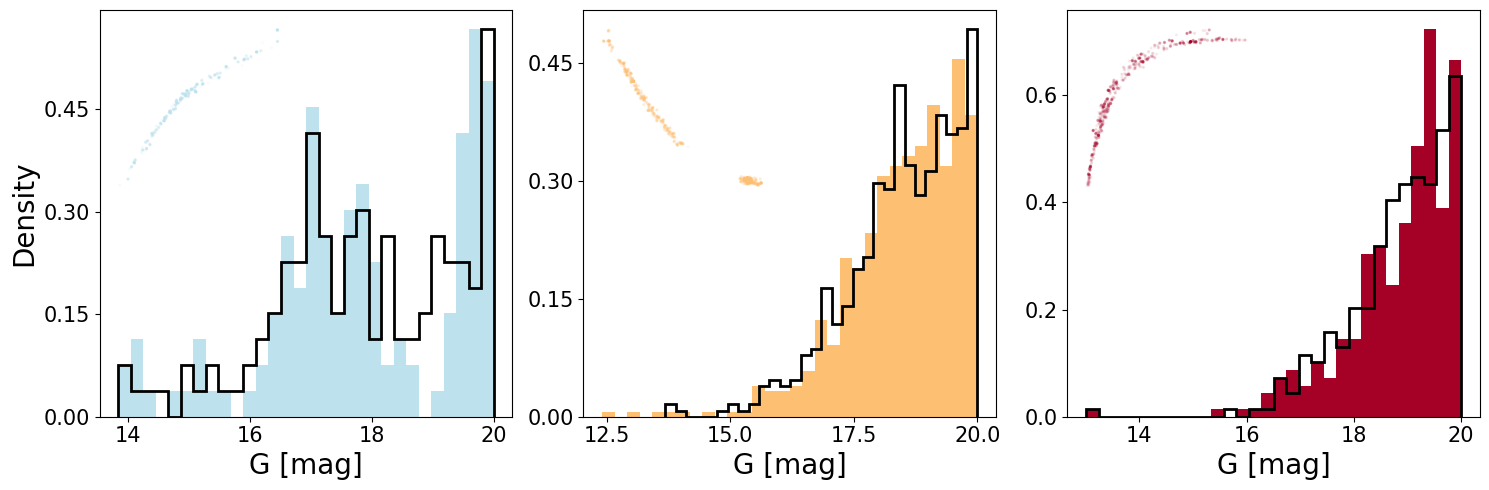

In [4]:
fig = plt.figure(figsize=(15, 5))
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, 4))
for i, name in enumerate(name_to_plot):
    ax = fig.add_subplot(1, 3, i+1)
    data = particles[name]['Gmag']
    ax.hist(data, bins=30, label=name, density=True, color=colors[i+1])
    kde = gaussian_kde(data)
    samples = kde.resample((len(data*10), )).reshape(len(data))
    samples = np.clip(samples, np.min(data), np.max(data))
    ax.hist(samples, bins=30, density=True, histtype='step', color='k', lw=2, label='KDE samples')
    ax.set_xlabel('G [mag]', fontsize=20)
    if i == 0:
        ax.set_ylabel('Density', fontsize=20)
    ax.xaxis.set_major_locator(plt.MaxNLocator(4))
    ax.yaxis.set_major_locator(plt.MaxNLocator(4))
    ax.tick_params(axis="both", labelsize=15)
    # ax.legend(fontsize=25)

    # --- Build per-point RGBA: same color as histogram, alpha ∝ 1/Gmag ---
    rgb = colors[i+1][:3]
    gmag = particles[name]['Gmag']
    alpha_vals = 1 - (gmag - gmag.min()) / (gmag.max() - gmag.min())
    alpha_vals = np.clip(alpha_vals, 0.05, 1.0)  # avoid fully invisible points
    rgba = np.column_stack([np.tile(rgb, (len(gmag), 1)), alpha_vals])

    # --- Inset: borderless Ra/Dec scatter ---
    ax_inset = ax.inset_axes([0.03, 0.55, 0.42, 0.42])
    ax_inset.scatter(
        particles[name]['Ra'],
        particles[name]['Dec'],
        c=rgba,
        s=2,
        rasterized=True,
    )
    # Remove the surrounding box and all ticks/labels
    for spine in ax_inset.spines.values():
        spine.set_visible(False)
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])

plt.tight_layout()

In [5]:
surveyid_to_survey = {
0: "no $v_{los}$",
1: "APOGEE",
2: "GALAH",
3: "Gaia RVS",
4: "LAMOST",
5: "S5",
6: "SDSS",
7: "BOSS",
8: "ESPaDOnS (this work)",
9: "AAOmega (from Ibata et al. 2017a [2017ApJ...842..120I])",
10: "FLAMES (from Ibata et al. 2017a [2017ApJ...842..120I])",
11: "UVES (from Odenkirchen et al. 2009 [2009AJ....137.3378O])",
12: "EFOSC (this work)",
13: "UVES (this work)",
14: "INT (this work)",
15: "Yuan et al. 2022a [2022MNRAS.514.1664Y]",
16: "Li et al. 2021 [2021ApJ...911..149L]",
17: "Caldwell et al. 2020 [2020AJ....159..287C]",
18: "Li et al. 2018b [2018ApJ...866...22L]",
19: "Koposov et al. 2018 [2018MNRAS.479.5343K]",
20: "Li et al. 2018a [2018ApJ...869..122L]",
21: "Simon et al. 2020 [2020ApJ...892..137S]",
22: "Walker et al. 2015 [2015ApJ...808..108W]",
23: "VIZIER",
24: "GES",
25: "DESI",
47: "not known"
}

# We want to know from where the Vhel are coming from 
for name in name_to_plot:
    print(f'{name} survey and counts:')
    r_vhel = particles[name]['r_VHel']
    survey_id, count = np.unique(r_vhel, return_counts=True)
    print('survey_id: ', [surveyid_to_survey[s] for s in survey_id])
    # print('survey_id: ', survey_id)
    print('survey count: ', count)

# ...existing code...
from collections import defaultdict

survey_counts = defaultdict(int)
for name in name_to_plot:
    r_vhel = particles[name]['r_VHel']
    survey_ids, counts = np.unique(r_vhel, return_counts=True)
    for sid, c in zip(survey_ids, counts):
        survey_name = surveyid_to_survey.get(int(sid), f"survey_{int(sid)}")
        survey_counts[survey_name] += int(c)

survey_counts = dict(survey_counts)

print(survey_counts)
# ...existing code...
    

Pal5 survey and counts:
survey_id:  ['no $v_{los}$', 'APOGEE', 'Gaia RVS', 'S5', 'AAOmega (from Ibata et al. 2017a [2017ApJ...842..120I])', 'FLAMES (from Ibata et al. 2017a [2017ApJ...842..120I])', 'UVES (from Odenkirchen et al. 2009 [2009AJ....137.3378O])', 'UVES (this work)']
survey count:  [60  2  3 11  7 14 12 20]
NGC3201 survey and counts:
survey_id:  ['no $v_{los}$', 'Gaia RVS', 'SDSS', 'ESPaDOnS (this work)', 'UVES (this work)', 'INT (this work)']
survey count:  [567   2   3   2  32   1]
M68 survey and counts:
survey_id:  ['no $v_{los}$', 'LAMOST', 'SDSS', 'BOSS', 'ESPaDOnS (this work)', 'EFOSC (this work)', 'VIZIER', 'DESI', 'not known']
survey count:  [268   5   8   2   3   1   1   8   1]
{'no $v_{los}$': 895, 'APOGEE': 2, 'Gaia RVS': 5, 'S5': 11, 'AAOmega (from Ibata et al. 2017a [2017ApJ...842..120I])': 7, 'FLAMES (from Ibata et al. 2017a [2017ApJ...842..120I])': 14, 'UVES (from Odenkirchen et al. 2009 [2009AJ....137.3378O])': 12, 'UVES (this work)': 52, 'SDSS': 11, 'ESPaDOn

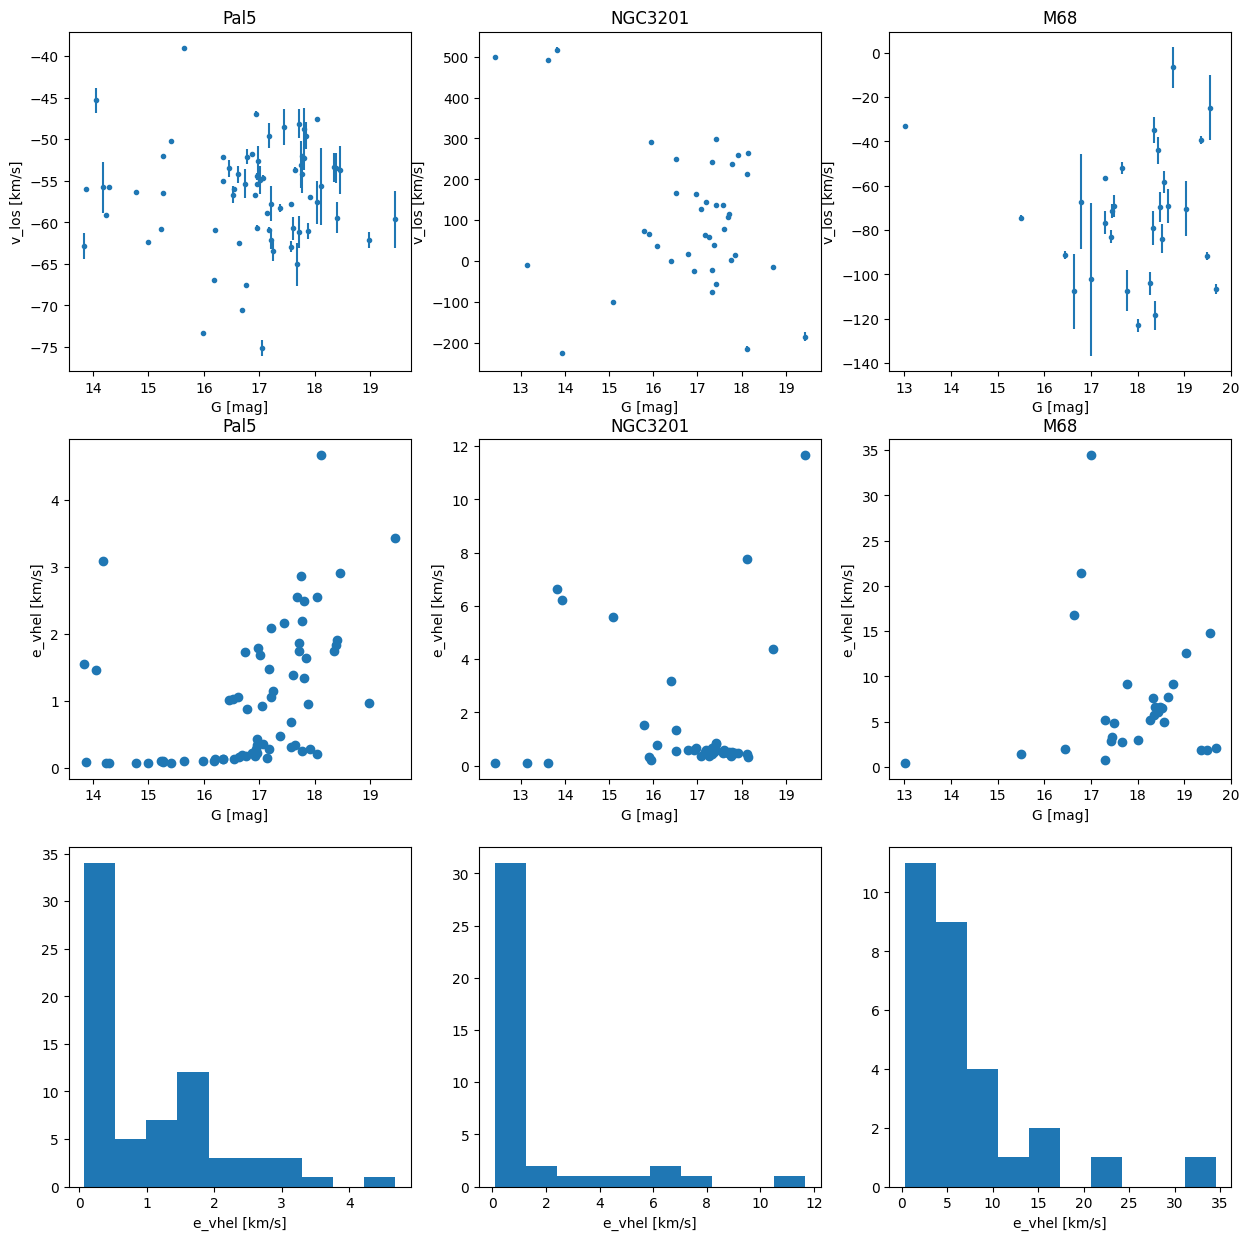

In [6]:
# We want to know from where the Vhel are coming from 
fig = plt.figure(figsize=(15, 15))
for name in name_to_plot:
    v_los = particles[name]['VHel']
    mask_vlos = v_los == 0.0
    e_vhel = particles[name]['e_VHel']
    magnitude = particles[name]['Gmag']

    ax = fig.add_subplot(3, 3, name_to_plot.index(name)+1)
    ax.errorbar(magnitude[~mask_vlos], v_los[~mask_vlos], yerr=e_vhel[~mask_vlos], fmt='.'  )
    ax.set_xlabel('G [mag]')
    ax.set_ylabel('v_los [km/s]')
    ax.set_title(name)

for name in name_to_plot:
    v_los = particles[name]['VHel']
    mask_vlos = v_los == 0.0
    e_vhel = particles[name]['e_VHel']
    magnitude = particles[name]['Gmag']

    ax = fig.add_subplot(3, 3, name_to_plot.index(name)+4)
    ax.scatter(magnitude[~mask_vlos], e_vhel[~mask_vlos], )
    ax.set_xlabel('G [mag]')
    ax.set_ylabel('e_vhel [km/s]')
    ax.set_title(name)

for name in name_to_plot:
    v_los = particles[name]['VHel']
    mask_vlos = v_los == 0.0
    e_vhel = particles[name]['e_VHel']

    ax = fig.add_subplot(3, 3, name_to_plot.index(name)+7)
    ax.hist(e_vhel[~mask_vlos], )
    ax.set_xlabel('e_vhel [km/s]')

# Galstreams

In [7]:
mws = galstreams.MWStreams(verbose=False, implement_Off=True, print_topcat_friendly_files=False);


Initializing galstreams library from master_log... 


        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use name instead. [gala.dynamics.core]
        Use n

Track name for Pal 5: ['Pal5-I24', 'Pal5-I21', 'Pal5-PW19', 'Pal5-S20']
Track name for NGC 3201: ['Gjoll-I21', 'Gjoll-I24', 'NGC3201-I21', 'NGC3201-P21']
Track name for M68: ['Fjorm-I21', 'Fjorm-I24', 'M68-I21', 'M68-P19']


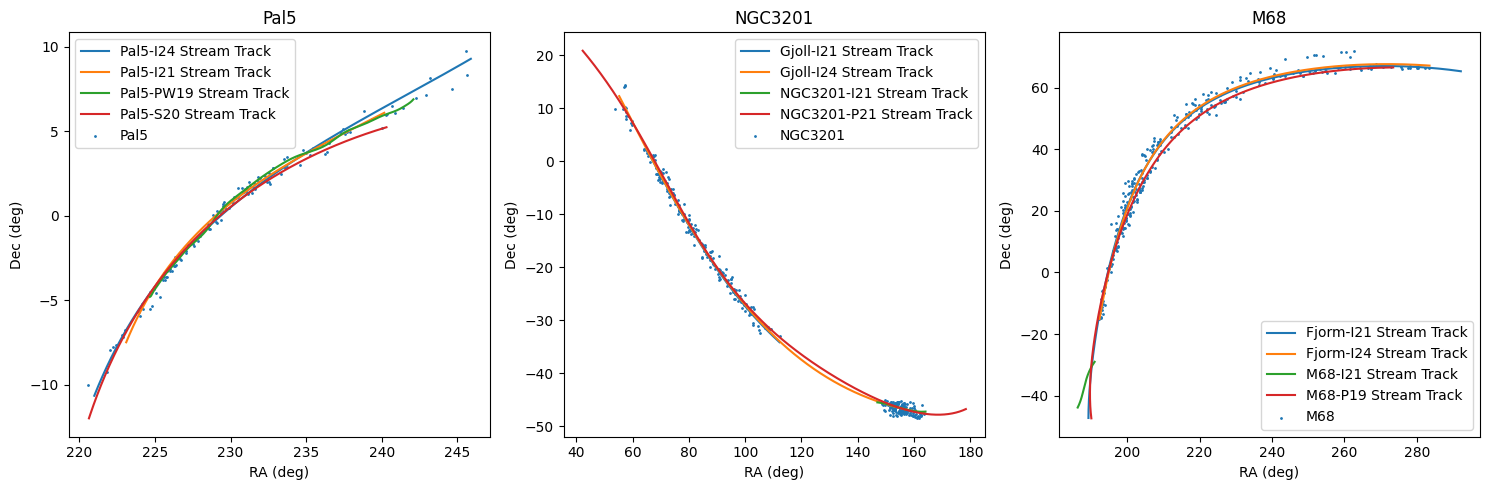

In [8]:
track_name_Pal5 = mws.get_track_names_for_stream('Pal5', On_only=True)
track_name_NGC3201 = mws.get_track_names_for_stream('NGC3201', On_only=True)
track_name_M68 = mws.get_track_names_for_stream('M68', On_only=True)

print("Track name for Pal 5:", track_name_Pal5)
print("Track name for NGC 3201:", track_name_NGC3201)
print("Track name for M68:", track_name_M68)


fig = plt.figure(figsize=(15,5), tight_layout=True)
ax = fig.add_subplot(131)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax2 = fig.add_subplot(132)
ax2.set_xlabel('RA (deg)')
ax2.set_ylabel('Dec (deg)')
ax3 = fig.add_subplot(133)
ax3.set_xlabel('RA (deg)')
ax3.set_ylabel('Dec (deg)')

for name in track_name_Pal5:
    track = mws[name].track
    ax.plot(track.ra, track.dec, label=f'{name} Stream Track', )

for name in track_name_NGC3201:
    track = mws[name].track
    ax2.plot(track.ra, track.dec, label=f'{name} Stream Track', )
# track_ngc3201 = mws[track_name_NGC3201[3]].track
# ax2.plot(track_ngc3201.ra, track_ngc3201.dec, label='NGC 3201 Stream Track', color='orange')

for name in track_name_M68:
    track = mws[name].track
    ax3.plot(track.ra, track.dec, label=f'{name} Stream Track', )
# track_m68 = mws[track_name_M68[0]].track
# ax3.plot(track_m68.ra, track_m68.dec, label='M68 Stream Track', color='green')


for i, name in enumerate(name_to_plot):
    if i==0:
        ax.scatter(particles[name]['Ra'], particles[name]['Dec'], s=1, label=name)
        ax.set_title(name)
    elif i==1:
        ax2.scatter(particles[name]['Ra'], particles[name]['Dec'], s=1, label=name)
        ax2.set_title(name)
    else:
        ax3.scatter(particles[name]['Ra'], particles[name]['Dec'], s=1, label=name)
        ax3.set_title(name)
    

ax.legend()
ax2.legend()
ax3.legend()



Pal5: 5-sigma width = 1.166 deg
NGC3201: 5-sigma width = 2.476 deg
M68: 5-sigma width = 9.326 deg


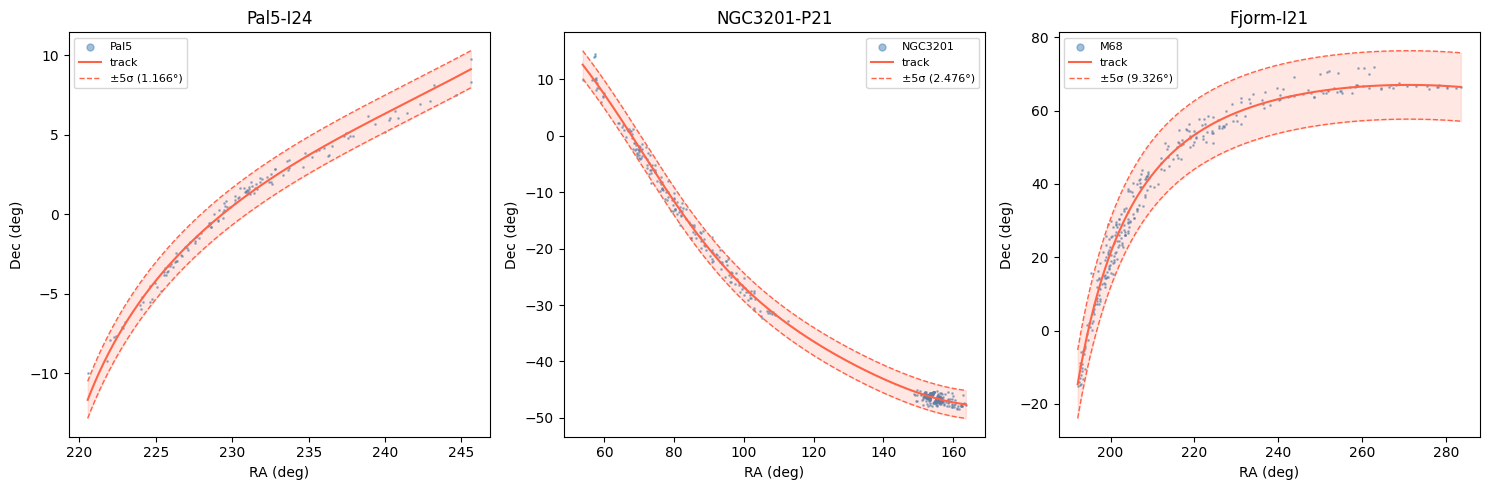

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline


def make_stream_mask(ra_track, dec_track, ra_data, dec_data, width_deg):
    ra_track  = np.asarray(ra_track, dtype=float)
    dec_track = np.asarray(dec_track, dtype=float)
    ra_data   = np.asarray(ra_data,  dtype=float)
    dec_data  = np.asarray(dec_data, dtype=float)

    order     = np.argsort(ra_track)
    ra_track  = ra_track[order]
    dec_track = dec_track[order]

    spl        = UnivariateSpline(ra_track, dec_track, s=0, k=3)
    dec_center = spl(ra_data)

    in_ra  = (ra_data >= ra_track.min()) & (ra_data <= ra_track.max())
    in_dec = np.abs(dec_data - dec_center) < width_deg
    return in_ra & in_dec, spl


# --- Track and stream configuration ---
track_names = ['Pal5-I24', 'NGC3201-P21', 'Fjorm-I21']

fig, axes = plt.subplots(1, 3, figsize=(15, 5), tight_layout=True)

for ax, track_name, stream_key in zip(axes, track_names, name_to_plot):
    ax.set_xlabel('RA (deg)')
    ax.set_ylabel('Dec (deg)')
    ax.set_title(track_name)

    # --- Track ---
    track    = mws[track_name].track
    ra_track = track.ra.value
    dec_track = track.dec.value
    np.savez(f'../data/{stream_key}_track.npz', ra=ra_track, dec=dec_track)

    ra_data  = np.asarray(particles[stream_key]['Ra'],  dtype=float)
    dec_data = np.asarray(particles[stream_key]['Dec'], dtype=float)

    # --- Compute residuals and 3-sigma width ---
    order     = np.argsort(ra_track)
    spl       = UnivariateSpline(ra_track[order], dec_track[order], s=0, k=3)

    in_ra      = (ra_data >= ra_track.min()) & (ra_data <= ra_track.max())
    dec_center = spl(ra_data[in_ra])
    residuals  = dec_data[in_ra] - dec_center
    width_deg  = 3.0 * np.std(residuals)
    print(f"{stream_key}: 5-sigma width = {width_deg:.3f} deg")

    # --- Scatter all data ---
    ax.scatter(ra_data, dec_data, s=1, color='steelblue', alpha=0.5, label=stream_key)

    # --- Plot the track and corridor box ---
    ra_dense      = np.linspace(ra_data.min(), ra_data.max(), 500)
    dec_dense     = spl(ra_dense)

    ax.plot(ra_dense, dec_dense,               color='tomato', lw=1.5, label='track')
    ax.plot(ra_dense, dec_dense + width_deg,   color='tomato', lw=1.0, ls='--', label=f'±5σ ({width_deg:.3f}°)')
    ax.plot(ra_dense, dec_dense - width_deg,   color='tomato', lw=1.0, ls='--')

    # Shade the corridor
    ax.fill_between(ra_dense,
                    dec_dense - width_deg,
                    dec_dense + width_deg,
                    color='tomato', alpha=0.15)

    ax.legend(markerscale=5, fontsize=8)

plt.show()

Track name for Pal 5: ['Pal5-I24', 'Pal5-I21', 'Pal5-PW19', 'Pal5-S20']
Track name for NGC 3201: ['Gjoll-I21', 'Gjoll-I24', 'NGC3201-I21', 'NGC3201-P21']
Track name for M68: ['Fjorm-I21', 'Fjorm-I24', 'M68-I21', 'M68-P19']


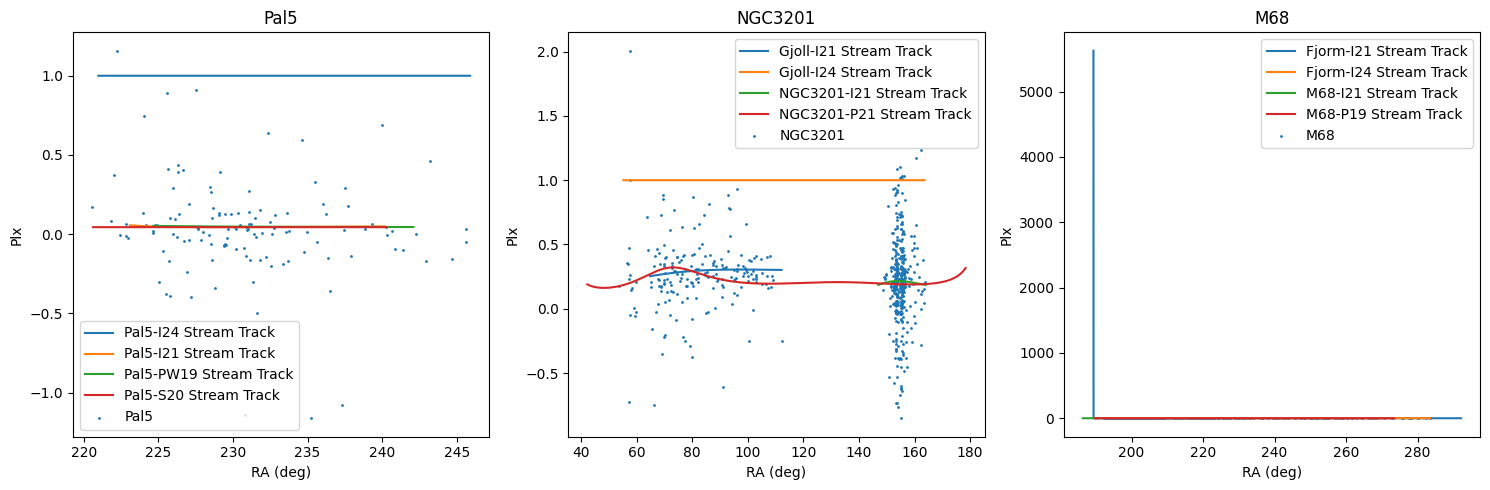

In [10]:
track_name_Pal5 = mws.get_track_names_for_stream('Pal5', On_only=True)
track_name_NGC3201 = mws.get_track_names_for_stream('NGC3201', On_only=True)
track_name_M68 = mws.get_track_names_for_stream('M68', On_only=True)

print("Track name for Pal 5:", track_name_Pal5)
print("Track name for NGC 3201:", track_name_NGC3201)
print("Track name for M68:", track_name_M68)


fig = plt.figure(figsize=(15,5), tight_layout=True)
ax = fig.add_subplot(131)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Plx')
ax2 = fig.add_subplot(132)
ax2.set_xlabel('RA (deg)')
ax2.set_ylabel('Plx')
ax3 = fig.add_subplot(133)
ax3.set_xlabel('RA (deg)')
ax3.set_ylabel('Plx')

for name in track_name_Pal5:
    track = mws[name].track
    ax.plot(track.ra, 1/track.distance, label=f'{name} Stream Track', )

for name in track_name_NGC3201:
    track = mws[name].track
    ax2.plot(track.ra, 1/track.distance, label=f'{name} Stream Track', )
# track_ngc3201 = mws[track_name_NGC3201[3]].track
# ax2.plot(track_ngc3201.ra, track_ngc3201.dec, label='NGC 3201 Stream Track', color='orange')

for name in track_name_M68:
    track = mws[name].track
    ax3.plot(track.ra, 1/track.distance, label=f'{name} Stream Track', )
# track_m68 = mws[track_name_M68[0]].track
# ax3.plot(track_m68.ra, track_m68.dec, label='M68 Stream Track', color='green')


for i, name in enumerate(name_to_plot):
    if i==0:
        ax.scatter(particles[name]['Ra'], particles[name]['Plx'], s=1, label=name)
        ax.set_title(name)
    elif i==1:
        ax2.scatter(particles[name]['Ra'], particles[name]['Plx'], s=1, label=name)
        ax2.set_title(name)
    else:
        ax3.scatter(particles[name]['Ra'], particles[name]['Plx'], s=1, label=name)
        ax3.set_title(name)
    

ax.legend()
ax2.legend()
ax3.legend()



Track name for Pal 5: ['Pal5-I24', 'Pal5-I21', 'Pal5-PW19', 'Pal5-S20']
Track name for NGC 3201: ['Gjoll-I21', 'Gjoll-I24', 'NGC3201-I21', 'NGC3201-P21']
Track name for M68: ['Fjorm-I21', 'Fjorm-I24', 'M68-I21', 'M68-P19']


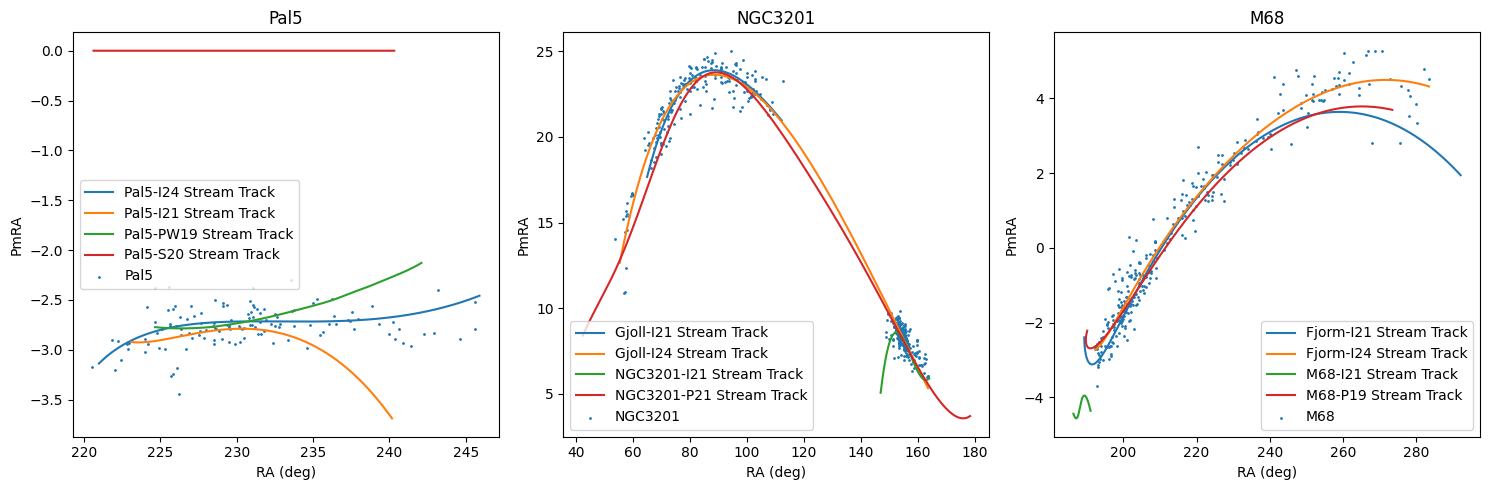

In [11]:
track_name_Pal5 = mws.get_track_names_for_stream('Pal5', On_only=True)
track_name_NGC3201 = mws.get_track_names_for_stream('NGC3201', On_only=True)
track_name_M68 = mws.get_track_names_for_stream('M68', On_only=True)

print("Track name for Pal 5:", track_name_Pal5)
print("Track name for NGC 3201:", track_name_NGC3201)
print("Track name for M68:", track_name_M68)


fig = plt.figure(figsize=(15,5), tight_layout=True)
ax = fig.add_subplot(131)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('PmRA')
ax2 = fig.add_subplot(132)
ax2.set_xlabel('RA (deg)')
ax2.set_ylabel('PmRA')
ax3 = fig.add_subplot(133)
ax3.set_xlabel('RA (deg)')
ax3.set_ylabel('PmRA')

for name in track_name_Pal5:
    track = mws[name].track
    ax.plot(track.ra, track.pm_ra_cosdec, label=f'{name} Stream Track', )

for name in track_name_NGC3201:
    track = mws[name].track
    ax2.plot(track.ra, track.pm_ra_cosdec, label=f'{name} Stream Track', )
# track_ngc3201 = mws[track_name_NGC3201[3]].track
# ax2.plot(track_ngc3201.ra, track_ngc3201.dec, label='NGC 3201 Stream Track', color='orange')

for name in track_name_M68:
    track = mws[name].track
    ax3.plot(track.ra, track.pm_ra_cosdec, label=f'{name} Stream Track', )
# track_m68 = mws[track_name_M68[0]].track
# ax3.plot(track_m68.ra, track_m68.dec, label='M68 Stream Track', color='green')


for i, name in enumerate(name_to_plot):
    if i==0:
        ax.scatter(particles[name]['Ra'], particles[name]['PmRA'], s=1, label=name)
        ax.set_title(name)
    elif i==1:
        ax2.scatter(particles[name]['Ra'], particles[name]['PmRA'], s=1, label=name)
        ax2.set_title(name)
    else:
        ax3.scatter(particles[name]['Ra'], particles[name]['PmRA'], s=1, label=name)
        ax3.set_title(name)
    

ax.legend()
ax2.legend()
ax3.legend()



Track name for Pal 5: ['Pal5-I24', 'Pal5-I21', 'Pal5-PW19', 'Pal5-S20']
Track name for NGC 3201: ['Gjoll-I21', 'Gjoll-I24', 'NGC3201-I21', 'NGC3201-P21']
Track name for M68: ['Fjorm-I21', 'Fjorm-I24', 'M68-I21', 'M68-P19']


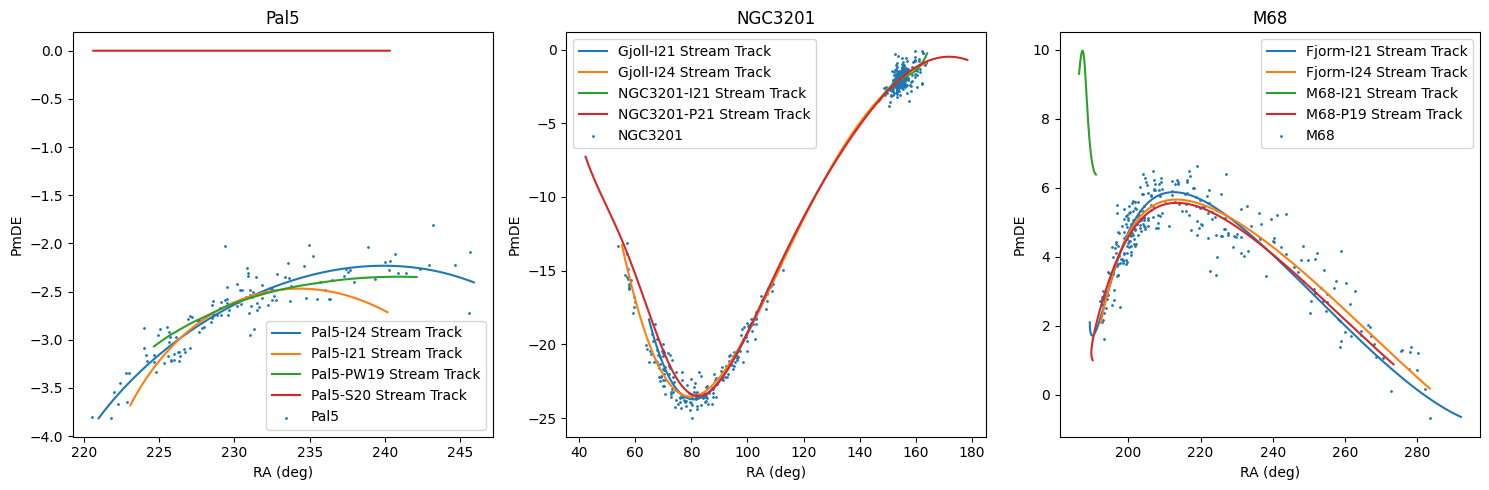

In [12]:
track_name_Pal5 = mws.get_track_names_for_stream('Pal5', On_only=True)
track_name_NGC3201 = mws.get_track_names_for_stream('NGC3201', On_only=True)
track_name_M68 = mws.get_track_names_for_stream('M68', On_only=True)

print("Track name for Pal 5:", track_name_Pal5)
print("Track name for NGC 3201:", track_name_NGC3201)
print("Track name for M68:", track_name_M68)


fig = plt.figure(figsize=(15,5), tight_layout=True)
ax = fig.add_subplot(131)
ax.set_xlabel('RA (deg)')
ax.set_ylabel('PmDE')
ax2 = fig.add_subplot(132)
ax2.set_xlabel('RA (deg)')
ax2.set_ylabel('PmDE')
ax3 = fig.add_subplot(133)
ax3.set_xlabel('RA (deg)')
ax3.set_ylabel('PmDE')

for name in track_name_Pal5:
    track = mws[name].track
    ax.plot(track.ra, track.pm_dec, label=f'{name} Stream Track', )

for name in track_name_NGC3201:
    track = mws[name].track
    ax2.plot(track.ra, track.pm_dec, label=f'{name} Stream Track', )
# track_ngc3201 = mws[track_name_NGC3201[3]].track
# ax2.plot(track_ngc3201.ra, track_ngc3201.dec, label='NGC 3201 Stream Track', color='orange')

for name in track_name_M68:
    track = mws[name].track
    ax3.plot(track.ra, track.pm_dec, label=f'{name} Stream Track', )
# track_m68 = mws[track_name_M68[0]].track
# ax3.plot(track_m68.ra, track_m68.dec, label='M68 Stream Track', color='green')


for i, name in enumerate(name_to_plot):
    if i==0:
        ax.scatter(particles[name]['Ra'], particles[name]['PmDE'], s=1, label=name)
        ax.set_title(name)
    elif i==1:
        ax2.scatter(particles[name]['Ra'], particles[name]['PmDE'], s=1, label=name)
        ax2.set_title(name)
    else:
        ax3.scatter(particles[name]['Ra'], particles[name]['PmDE'], s=1, label=name)
        ax3.set_title(name)
    

ax.legend()
ax2.legend()
ax3.legend()



# Extract Gaia stream data

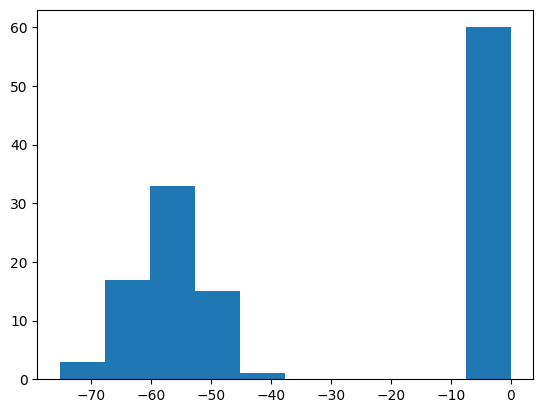

Filling 129 stars for Pal5
Pal5: 129.0 stars (padding to 1000)


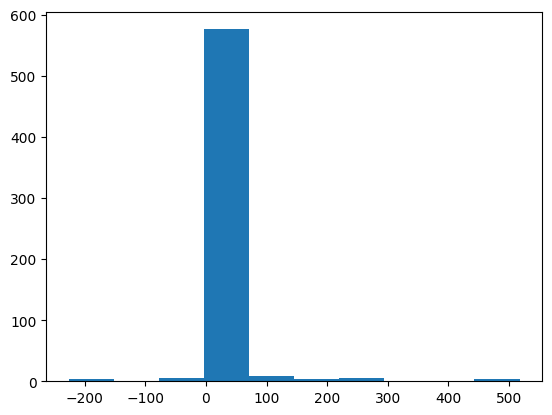

Filling 607 stars for NGC3201
NGC3201: 195.0 stars (padding to 1000)


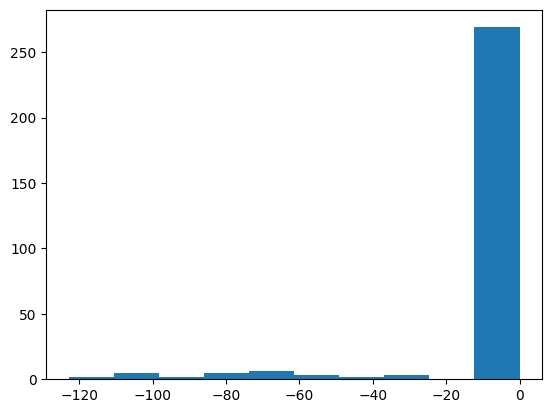

Filling 297 stars for M68
M68: 297.0 stars (padding to 1000)
sim_data_projected shape: (1, 3, 1000, 6)
attention_mask shape: (3, 1, 1000)
magnitudes shape: (3, 1000)
vlos_error shape: (3, 1000)
vlos_mask shape: (3, 1000)
j: [[[0]
  [1]
  [2]]]
Saved to ../data/gaia_observed_streams_6Dwitherrors_cutNGC3201.npz


In [23]:
# Cell to add after particles['Pal5'].keys()

name_to_plot = ['Pal5', 'NGC3201', 'M68']
N_max = 1000
n_features = 6

# Shape: (1, 3, 1000, 6)
sim_data_projected = np.zeros((1, len(name_to_plot), N_max, n_features),)
# Shape: (3, 1000) initially, will add middle dim at the end
attention_mask = np.zeros((len(name_to_plot), N_max))
#magnitudes (1, 3, 1000, 1)
magnitudes = np.zeros((len(name_to_plot), N_max),)
vlos_error = np.zeros((len(name_to_plot), N_max,),)
vlos_mask = np.zeros((len(name_to_plot), N_max,),) #we mask the stars who do not have v_los measurements (v_los = 0.0)

for i, name in enumerate(name_to_plot):
    p = particles[name]
    n_stars = len(p['Ra'])
    # print(f"{name}: {n_stars} stars (padding to {N_max})")
    
    # Stack the 6 features: Ra, Dec, Plx, PmRA, PmDE, VHel
    data = np.column_stack([
        p['Ra'],
        p['Dec'],
        p['Plx'],
        p['PmRA'],
        p['PmDE'],
        p['VHel'],
    ])  # shape: (n_stars, 6)
    mag = p['Gmag'].reshape(-1, 1)  # shape: (n_stars, 1)
    v_los_err = p['e_VHel'].reshape(-1, 1)  # shape: (n_stars, 1)
    plt.hist(p['VHel'],)
    plt.show()
    # Fill into the array (pad with zeros if n_stars < N_max)
    n_fill = min(n_stars, N_max)
    print(f"Filling {n_fill} stars for {name}")
    sim_data_projected[0, i, :n_fill, :] = data[:n_fill]
    if name == 'NGC3201':
        sim_data_projected[0, i][sim_data_projected[0, i, :, 0] > 140.0] = 0.0
    
    # Set attention mask to 1 where there are real stars
    attention_mask[i, :n_fill] = 1.0
    if name == 'NGC3201':
        attention_mask[i, :][sim_data_projected[0, i, :, 0] == 0.0] = 0
    
    print(f"{name}: {np.sum(attention_mask[i])} stars (padding to {N_max})")

    #Set magnitudes
    magnitudes[i, :n_fill] = mag[:n_fill, 0]

    #Set velocity errors
    vlos_error[i, :n_fill] = v_los_err[:n_fill, 0]
    
    if name == 'NGC3201':
        vlos_mask[i, :n_fill] = (p['VHel'] != 0.0)&(p['Ra']<140)
    else:
        vlos_mask[i, :n_fill] = (p['VHel'] != 0.0) #mask for VHel = 0.0 (i.e., we have a valid v_los measurement)


# Add the middle dimension: (1, 3, 1000) -> (1, 3, 1, 1000)
attention_mask = attention_mask[:, np.newaxis, :]

# j array mapping: 0 -> Pal5, 1 -> NGC3201, 2 -> M68
j = np.array([0, 1, 2]).reshape(1, len(name_to_plot), 1)

print(f"sim_data_projected shape: {sim_data_projected.shape}")
print(f"attention_mask shape: {attention_mask.shape}")
print(f"magnitudes shape: {magnitudes.shape}")
print(f"vlos_error shape: {vlos_error.shape}")
print(f"vlos_mask shape: {vlos_mask.shape}")
print(f"j: {j}")

np.savez(
    "../data/gaia_observed_streams_6Dwitherrors_cutNGC3201.npz",
    j=j,
    sim_data_projected=sim_data_projected,
    attention_mask=attention_mask,
    magnitudes=magnitudes,
    vlos_error=vlos_error,
    vlos_mask=vlos_mask
)
print("Saved to ../data/gaia_observed_streams_6Dwitherrors_cutNGC3201.npz")

Filling 129 stars for Pal5
Pal5 VHel stats -> mean: -56.70, std: 6.27


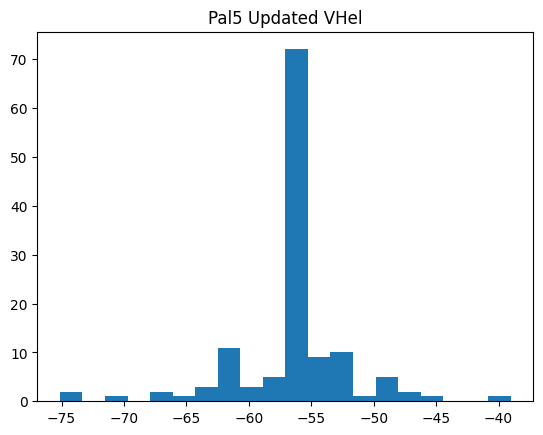

Pal5: 129.0 active stars (padded to 1000)
Filling 607 stars for NGC3201
NGC3201 VHel stats -> mean: 72.03, std: 135.04


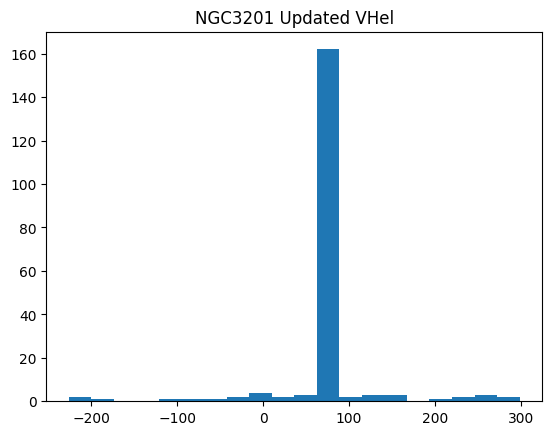

NGC3201: 195.0 active stars (padded to 1000)
Filling 297 stars for M68
M68 VHel stats -> mean: -72.98, std: 28.53


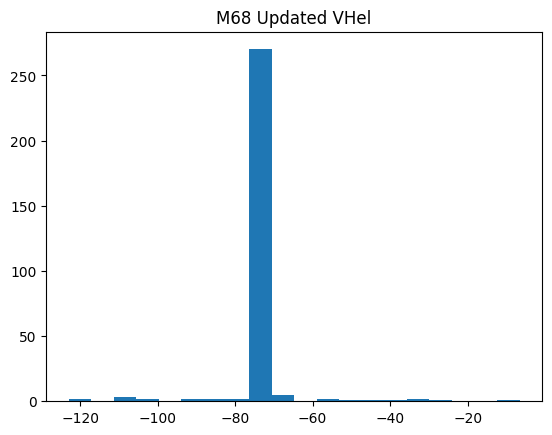

M68: 297.0 active stars (padded to 1000)

sim_data_projected shape: (1, 3, 1000, 6)
attention_mask shape: (3, 1, 1000)
magnitudes shape: (3, 1000)
vlos_error shape: (3, 1000)
vlos_mask shape: (3, 1000)
j: [0 1 2]
Saved to ../data/gaia_observed_streams_6Dwitherrors_cutNGC3201.npz


In [13]:
# Cell to add after particles['Pal5'].keys()

name_to_plot = ['Pal5', 'NGC3201', 'M68']
N_max = 1000
n_features = 6

# Shape: (1, 3, 1000, 6)
sim_data_projected = np.zeros((1, len(name_to_plot), N_max, n_features),)
# Shape: (3, 1000) initially, will add middle dim at the end
attention_mask = np.zeros((len(name_to_plot), N_max))
#magnitudes (1, 3, 1000, 1)
magnitudes = np.zeros((len(name_to_plot), N_max),)
vlos_error = np.zeros((len(name_to_plot), N_max,),)
vlos_mask = np.zeros((len(name_to_plot), N_max,),) #we mask the stars who do not have v_los measurements (v_los = 0.0)

for i, name in enumerate(name_to_plot):
    p = particles[name]
    n_stars = len(p['Ra'])
    n_fill = min(n_stars, N_max)
    print(f"Filling {n_fill} stars for {name}")
    
    # 1. Define spatial mask to exclude specific stars (like NGC3201 Ra > 140)
    if name == 'NGC3201':
        spatial_mask = p['Ra'][:n_fill] <= 140.0
    else:
        spatial_mask = np.ones(n_fill, dtype=bool)

    # 2. Identify stars with valid v_los measurements inside the spatial window
    has_vlos = p['VHel'][:n_fill] != 0.0
    valid_vlos_mask = spatial_mask & has_vlos
    
    # 3. Calculate mean and std of valid v_los
    valid_vlos_values = p['VHel'][:n_fill][valid_vlos_mask]
    mean_vhel = np.mean(valid_vlos_values)
    std_vhel = np.std(valid_vlos_values)
    print(f"{name} VHel stats -> mean: {mean_vhel:.2f}, std: {std_vhel:.2f}")

    # 4. Copy original values to safely modify them
    mod_vhel = p['VHel'][:n_fill].copy()
    mod_e_vhel = p['e_VHel'][:n_fill].copy()

    # 5. Apply the imputation for missing VHel *inside* the spatial mask
    missing_vlos_mask = spatial_mask & ~has_vlos
    mod_vhel[missing_vlos_mask] = mean_vhel
    mod_e_vhel[missing_vlos_mask] = std_vhel
    
    plt.hist(mod_vhel[spatial_mask], bins=20)
    plt.title(f"{name} Updated VHel")
    plt.show()

    # 6. Stack the 6 features using the updated VHel
    data = np.column_stack([
        p['Ra'][:n_fill],
        p['Dec'][:n_fill],
        p['Plx'][:n_fill],
        p['PmRA'][:n_fill],
        p['PmDE'][:n_fill],
        mod_vhel
    ])
    
    # Set all features to 0.0 for stars outside the spatial mask
    data[~spatial_mask] = 0.0

    # Fill into the array
    sim_data_projected[0, i, :n_fill, :] = data
    
    # Set attention mask to 1 where there are valid geometric stars
    attention_mask[i, :n_fill][spatial_mask] = 1.0
    print(f"{name}: {np.sum(attention_mask[i])} active stars (padded to {N_max})")

    # Set magnitudes (zero out excluded)
    mag = p['Gmag'][:n_fill].copy()
    mag[~spatial_mask] = 0.0
    magnitudes[i, :n_fill] = mag

    # Set velocity errors (zero out excluded)
    mod_e_vhel[~spatial_mask] = 0.0
    vlos_error[i, :n_fill] = mod_e_vhel
    
    # Set vlos_mask to True ONLY for stars that strictly had a measurement and are geometrically valid
    vlos_mask[i, :n_fill] = valid_vlos_mask

# Add the middle dimension: (1, 3, 1000) -> (1, 3, 1, 1000)
attention_mask = attention_mask[:, np.newaxis, :]

# j array mapping: 0 -> Pal5, 1 -> NGC3201, 2 -> M68
j = np.array([0, 1, 2]).reshape(1, len(name_to_plot), 1)

print(f"\nsim_data_projected shape: {sim_data_projected.shape}")
print(f"attention_mask shape: {attention_mask.shape}")
print(f"magnitudes shape: {magnitudes.shape}")
print(f"vlos_error shape: {vlos_error.shape}")
print(f"vlos_mask shape: {vlos_mask.shape}")
print(f"j: {j.flatten()}")

np.savez(
    "../data/gaia_observed_streams_6Dwitherrors_cutNGC3201.npz",
    j=j,
    sim_data_projected=sim_data_projected,
    attention_mask=attention_mask,
    magnitudes=magnitudes,
    vlos_error=vlos_error,
    vlos_mask=vlos_mask
)
print("Saved to ../data/gaia_observed_streams_6Dwitherrors_cutNGC3201.npz")

In [14]:
print('vlos mask length of non 0 values:')
print(np.sum(vlos_mask[1, :,]))

vlos mask length of non 0 values:
37.0


Loaded sim_data shape: (1, 3, 1000, 6)
Loaded j shape: (1, 3, 1)


/tmp/ipykernel_2898307/1250081692.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(sim_data[0, i, attention_mask[i, 0, :], 0], sim_data[0, i, attention_mask[i, 0, :], 1], s=1, label=f"{name_to_plot[i]}", c=colors[i+1])


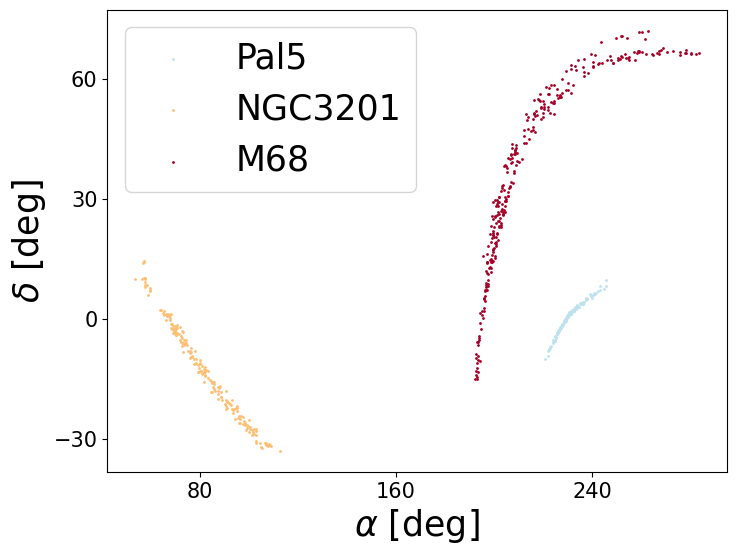

In [18]:
data = np.load("../data/gaia_observed_streams_6Dwitherrors_cutNGC3201.npz")
sim_data = data['sim_data_projected']
j = data['j']
name_to_plot = ['Pal5', 'NGC3201', 'M68']

print(f"Loaded sim_data shape: {sim_data.shape}")
print(f"Loaded j shape: {j.shape}")
attention_mask = data['attention_mask'].astype(bool)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
for i in range(sim_data.shape[1]):
    ax.scatter(sim_data[0, i, attention_mask[i, 0, :], 0], sim_data[0, i, attention_mask[i, 0, :], 1], s=1, label=f"{name_to_plot[i]}", c=colors[i+1])
ax.legend(fontsize=25)
ax.set_xlabel('$\\alpha$ [deg]', fontsize=25)
ax.set_ylabel('$\\delta$ [deg]', fontsize=25)
ax.xaxis.set_major_locator(plt.MaxNLocator(4))
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
ax.tick_params(axis="both", labelsize=15)
fig.savefig('../data/plots/gaia_observed_streams_6Dwitherrors_cutNGC3201.pdf', dpi=300, bbox_inches='tight')

Loaded sim_data shape: (1, 3, 1000, 6)
Loaded j shape: (1, 3, 1)


/tmp/ipykernel_1036424/2283537920.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(sim_data[0, i, attention_mask[i, 0, :], 0], sim_data[0, i, attention_mask[i, 0, :], -1], s=1, label=f"{name_to_plot[i]}", c=colors[i+1])


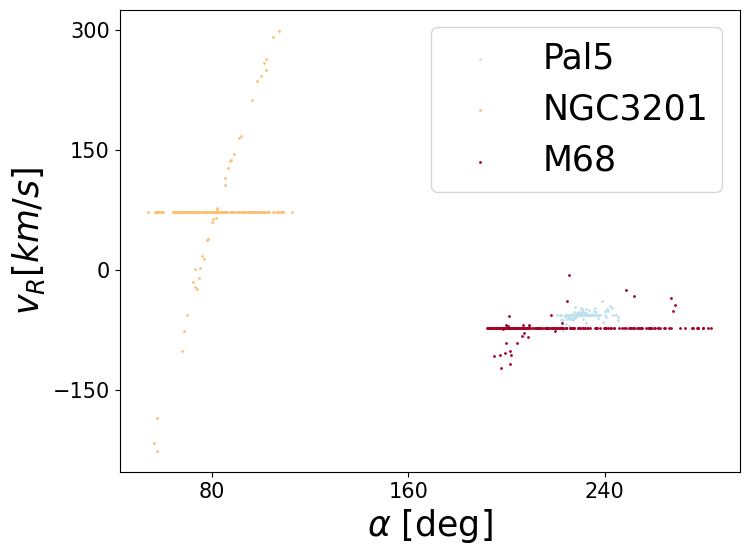

In [28]:
data = np.load("../data/gaia_observed_streams_6Dwitherrors_cutNGC3201.npz")
sim_data = data['sim_data_projected']
j = data['j']
name_to_plot = ['Pal5', 'NGC3201', 'M68']

print(f"Loaded sim_data shape: {sim_data.shape}")
print(f"Loaded j shape: {j.shape}")
attention_mask = data['attention_mask'].astype(bool)
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111)
for i in range(sim_data.shape[1]):
    ax.scatter(sim_data[0, i, attention_mask[i, 0, :], 0], sim_data[0, i, attention_mask[i, 0, :], -1], s=1, label=f"{name_to_plot[i]}", c=colors[i+1])
ax.legend(fontsize=25)
ax.set_xlabel('$\\alpha$ [deg]', fontsize=25)
ax.set_ylabel('$v_{R} [km/s]$', fontsize=25)
ax.xaxis.set_major_locator(plt.MaxNLocator(4))
ax.yaxis.set_major_locator(plt.MaxNLocator(4))
ax.tick_params(axis="both", labelsize=15)

/tmp/ipykernel_877181/198500705.py:12: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(ra_rad, dec_rad, s=1, label=name_to_plot[i], c=colors[i+1], rasterized=True)


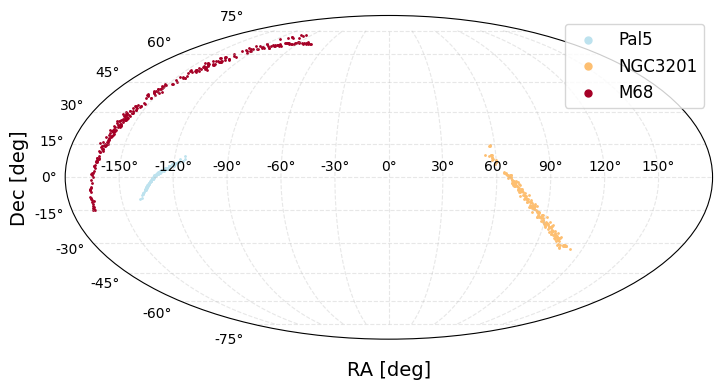

In [50]:
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(111, projection='mollweide')

for i in range(sim_data.shape[1]):
    ra  = sim_data[0, i, attention_mask[i, 0, :], 0]
    dec = sim_data[0, i, attention_mask[i, 0, :], 1]

    # Convert to radians; wrap RA from [0, 360] → [-π, π]
    ra_rad  = np.deg2rad((ra + 180) % 360 - 180)
    dec_rad = np.deg2rad(dec)

    ax.scatter(ra_rad, dec_rad, s=1, label=name_to_plot[i], c=colors[i+1], rasterized=True)

# Astronomical convention: RA increases to the left
# ax.invert_xaxis()

# Replace radian tick labels with degree labels
# ax.set_xticklabels([f'{d}°' for d in [150, 90, 60, 30, 0, 330, 300, 270, 240, 210]])
ax.set_xlabel('RA [deg]', fontsize=14, labelpad=15)
ax.set_ylabel('Dec [deg]', fontsize=14)
ax.legend(fontsize=12, markerscale=5)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

Loaded sim_data shape: (1, 3, 1000, 6)
Loaded j shape: (1, 3, 1)


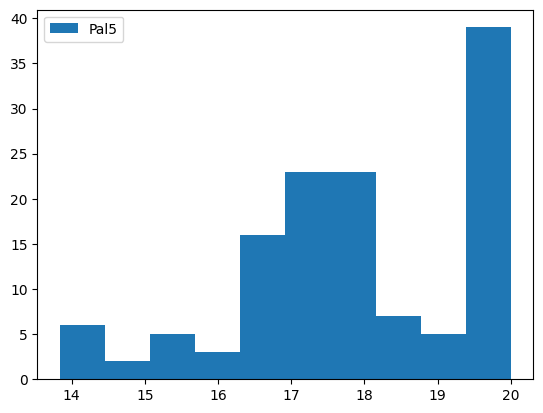

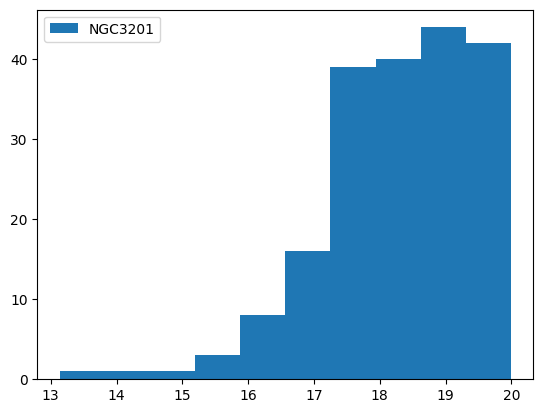

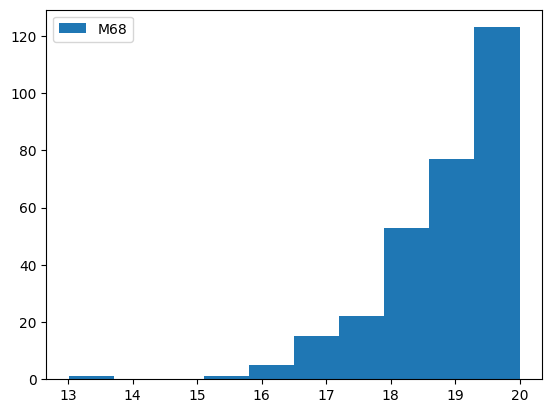

In [14]:
print(f"Loaded sim_data shape: {sim_data.shape}")
print(f"Loaded j shape: {j.shape}")
attention_mask = data['attention_mask'].astype(bool)
for i in range(sim_data.shape[1]):
    plt.hist(magnitudes[i, attention_mask[i, 0, :]], label=f"{name_to_plot[i]}")
    plt.legend()
    plt.show()
    


Loaded sim_data shape: (1, 3, 1000, 6)
Loaded j shape: (1, 3, 1)


Text(0, 0.5, '$\\delta$ ')

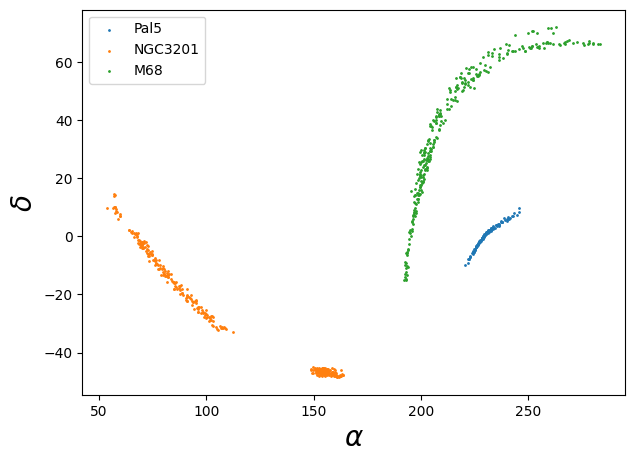

In [2]:
data = np.load("../data/gaia_observed_streams.npz")
sim_data = data['sim_data_projected']
j = data['j']
name_to_plot = ['Pal5', 'NGC3201', 'M68']

print(f"Loaded sim_data shape: {sim_data.shape}")
print(f"Loaded j shape: {j.shape}")
attention_mask = data['attention_mask'].astype(bool)
fig = plt.figure(figsize=(7, 5))
for i in range(sim_data.shape[1]):
    plt.scatter(sim_data[0, i, attention_mask[i, 0, :], 0], sim_data[0, i, attention_mask[i, 0, :], 1], s=1, label=f"{name_to_plot[i]}")
plt.legend()
plt.xlabel('$\\alpha$ ', fontsize=20)
plt.ylabel('$\\delta$ ', fontsize=20)

Loaded sim_data shape: (1, 3, 1000, 6)
Loaded j shape: (1, 3, 1)


Text(0, 0.5, '$\\delta$ ')

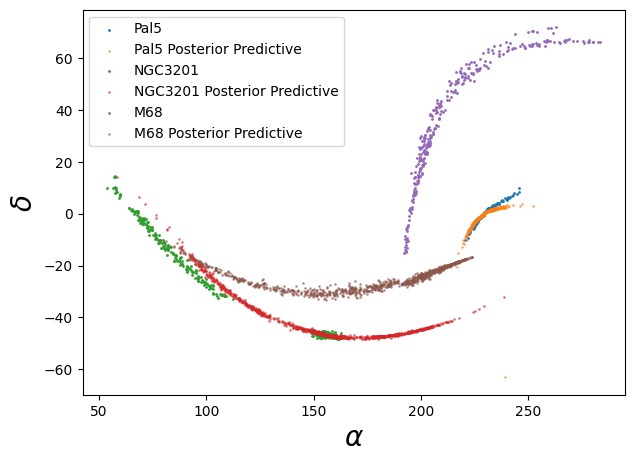

In [7]:
data = np.load("../data/gaia_observed_streams.npz")
sim_data = data['sim_data_projected']
j = data['j']
name_to_plot = ['Pal5', 'NGC3201', 'M68']
posterior_sample = np.load('/export/data/vgiusepp/diffusion_experiments_test_new/diffusion-experiments/case_study5/project_stream/data/streams/data_multistream_gala_posterior_predictive_check/model_54_60k_1000epochs/simulation_multistream_1.npz')
posteriorpredictive_sample = posterior_sample['sim_data_projected'] 

print(f"Loaded sim_data shape: {sim_data.shape}")
print(f"Loaded j shape: {j.shape}")
attention_mask = data['attention_mask'].astype(bool)
fig = plt.figure(figsize=(7, 5))
for i in range(sim_data.shape[1]):
    plt.scatter(sim_data[0, i, attention_mask[i, 0, :], 0], sim_data[0, i, attention_mask[i, 0, :], 1], s=1, label=f"{name_to_plot[i]}")
    plt.scatter(posteriorpredictive_sample[0, i,:,  0], posteriorpredictive_sample[0, i, :, 1], s=1, label=f"{name_to_plot[i]} Posterior Predictive", alpha=0.5)
plt.legend()
plt.xlabel('$\\alpha$ ', fontsize=20)
plt.ylabel('$\\delta$ ', fontsize=20)

In [ ]:
# posteriorpredictive_sample.shape

(1, 3, 1002, 6)

Loaded sim_data shape: (1, 3, 1000, 6)
Loaded posteriorpredictive_sample shape: (10, 3, 1002, 6)
Loaded sim_data shape: (1, 3, 1000, 6)
Loaded j shape: (1, 3, 1)


Text(0, 0.5, '$\\delta$ ')

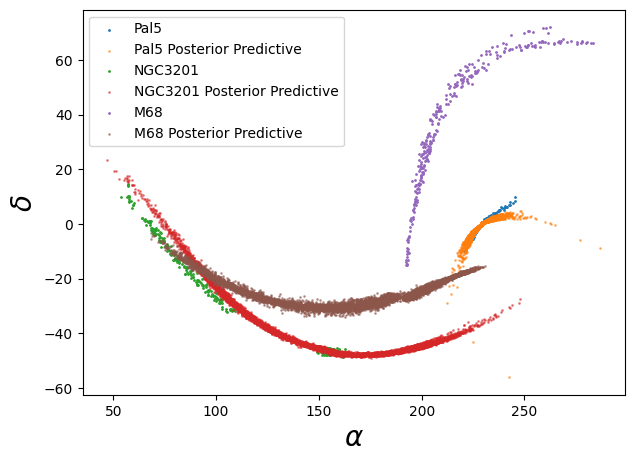

In [8]:
data = np.load("../data/gaia_observed_streams.npz")
sim_data = data['sim_data_projected']
j = data['j']
name_to_plot = ['Pal5', 'NGC3201', 'M68']
posterior_sample = np.load('/export/data/vgiusepp/diffusion_experiments_test_new/diffusion-experiments/case_study5/project_stream/data/streams/data_multistream_gala_posterior_predictive_check/model_54_60k_1000epochs/ppc_10samples.npz')
posteriorpredictive_sample = posterior_sample['sim_data_projected'] 
print(f"Loaded sim_data shape: {sim_data.shape}")
print(f"Loaded posteriorpredictive_sample shape: {posteriorpredictive_sample.shape}")

print(f"Loaded sim_data shape: {sim_data.shape}")
print(f"Loaded j shape: {j.shape}")
attention_mask = data['attention_mask'].astype(bool)
fig = plt.figure(figsize=(7, 5))
for i in range(sim_data.shape[1]):
    plt.scatter(sim_data[0, i, attention_mask[i, 0, :], 0], sim_data[0, i, attention_mask[i, 0, :], 1], s=1, label=f"{name_to_plot[i]}")
    plt.scatter(posteriorpredictive_sample[:, i,:,  0], posteriorpredictive_sample[:, i, :, 1], s=1, label=f"{name_to_plot[i]} Posterior Predictive", alpha=0.5)
plt.legend()
plt.xlabel('$\\alpha$ ', fontsize=20)
plt.ylabel('$\\delta$ ', fontsize=20)